# Causal AI Fairness — Example 5

In this notebook, we reproduce **Example 5** from the paper *Automatic Causal Fairness Analysis with LLM-Generated Reporting*.  
The goal is to demonstrate a compact end-to-end causal fairness analysis workflow.

In particular, we will:

- load a processed dataset
- define a Structural Fairness Model (SFM)
- fit a discrete Bayesian network
- compute observational and causal fairness effects
- inspect the distributions of the effects together with the stepwise effects

## 1. Imports and repository setup

The cell below makes the notebook robust whether it is launched from the repository root or from the notebooks directory.

In [63]:
import sys
!{sys.executable} -m pip install daft-pgm

In [64]:
from pathlib import Path
import sys

import pandas as pd
from pgmpy.estimators import BayesianEstimator

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

from src.effects import DE, IE, SE, TE, TV, effect_distribution, utility_weighted_effect
from src.graph import build_sfm
from src.model import fit_discrete_bayesian_model
from src.sym.dsl import Variable
from src.sym.effects import symbolic_NDE, symbolic_total_effect
from src.visualisation.graph import visualize_sfm

REPO_ROOT

PosixPath('/Users/alessiaberarducci/Desktop/WireGuard/causal-ai-fairness')

## 2. Load and prepare data

We reuse the processed Adult dataset and consider `education` as an ordered categorical variable in the discrete Bayesian network.

In [65]:
data_path = REPO_ROOT / "data" / "processed" / "adult.csv"
df = pd.read_csv(data_path)
selected_columns = [
    "education",
    "native-country",
    "S2_gender",
    "T_income",
]

df[selected_columns].head()


,education,native-country,S2_gender,T_income
0,11th,United-States,Male,<=50K
1,HS-grad,United-States,Male,<=50K
2,Assoc-acdm,United-States,Male,>50K
3,Some-college,United-States,Male,>50K
4,Some-college,United-States,Female,<=50K


In [66]:
df["education"].dtype
df["education"] = df["education"].astype("category")
df["native-country"].dtype
df["native-country"] = df["native-country"].astype("category")
df["S2_gender"].dtype
df["S2_gender"] = df["S2_gender"].astype("category")
df["T_income"].dtype
df["T_income"] = df["T_income"].astype("category")

In [67]:
education_order = [
    "Preschool",
    "1st-4th",
    "5th-6th",
    "7th-8th",
    "9th",
    "10th",
    "11th",
    "12th",
    "HS-grad",
    "Some-college",
    "Assoc-voc",
    "Assoc-acdm",
    "Bachelors",
    "Masters",
    "Prof-school",
    "Doctorate",
]

In [68]:
df["education"] = pd.Categorical(
    df["education"],
    categories=education_order,
    ordered=True
)

In [69]:
df[selected_columns].nunique().rename("cardinality")

education         16
native-country    42
S2_gender          2
T_income           2
Name: cardinality, dtype: int64

## 3. Define the Structural Fairness Model

This graph encodes one sensitive attribute, one observed confounder, one mediator, and one outcome.

In [70]:
private_attr = "education"
outcome_attr = "T_income"
confounders = ["S2_gender"]
mediators = ["native-country"]

sfm = build_sfm(
    sensitive_attr=private_attr,
    outcome_attr=outcome_attr,
    confounder_attrs=confounders,
    mediator_attrs=mediators,
)

sorted(sfm.edges())

[('S2_gender', 'T_income'),
 ('S2_gender', 'education'),
 ('S2_gender', 'native-country'),
 ('education', 'T_income'),
 ('education', 'native-country'),
 ('native-country', 'T_income')]

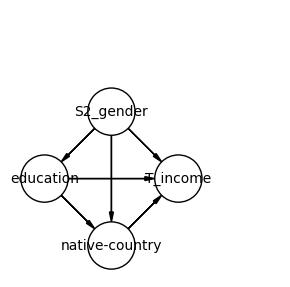

In [71]:
visualize_sfm(sfm)

## 4. Fit the Bayesian network

`fit_discrete_bayesian_model` keeps the SFM structure fixed and estimates the conditional distributions from the data.

In [72]:
bn = fit_discrete_bayesian_model(
    sfm=sfm,
    data=df[selected_columns],
    estimator_instance=(
        BayesianEstimator,
        {"prior_type": "dirichlet", "pseudo_counts": 1.0},
    ),
)

assert bn.check_model()
bn

2026-03-10 10:34:31.432 | DEBUG    | src.model:fit_discrete_bayesian_model:33 - Using estimator: <class 'pgmpy.estimators.BayesianEstimator.BayesianEstimator'> with parameters: {'prior_type': 'dirichlet', 'pseudo_counts': 1.0}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'education': 'O', 'native-country': 'C', 'S2_gender': 'C', 'T_income': 'C'}


In [73]:
pd.Series(
    {node: bn.get_cpds(node).state_names[node] for node in bn.nodes}, name="states"
)

education         [10th, 11th, 12th, 1st-4th, 5th-6th, 7th-8th, ...
T_income                                              [<=50K, >50K]
S2_gender                                            [Female, Male]
native-country    [Cambodia, Canada, China, Columbia, Cuba, Domi...
Name: states, dtype: object

## 5. Compute core fairness effects

We evaluate the probability of the `>50K` outcome when comparing `Some College` to `Masters`.

In [74]:
target = (outcome_attr, ">50K")
x0 = "Some-college"
x1 = "Masters"

results = pd.Series(
    {
        "TV": TV(bn, target, private_attr, x0, x1),
        "TE": TE(bn, target, private_attr, x0, x1),
        "SE(x0)": SE(bn, target, private_attr, x0),
        "SE(x1)": SE(bn, target, private_attr, x1),
        "NDE": DE(bn, target, private_attr, x0, x1),
        "NIE": IE(bn, target, private_attr, x1, x0),
    },
    name="effect",
)

results.round(4)

2026-03-10 10:34:31.460 | DEBUG    | src.effects:total_variation:247 - Computing total variation for target=('T_income', '>50K'), private_baseline=Some-college, private_mod=Masters
2026-03-10 10:34:31.464 | DEBUG    | src.effects:spurious_effect:194 - Computing spurious effect for target=('T_income', '>50K'), private_value=Some-college
2026-03-10 10:34:31.465 | DEBUG    | src.effects:spurious_effect:194 - Computing spurious effect for target=('T_income', '>50K'), private_value=Masters


TV        0.3558
TE        0.3419
SE(x0)   -0.0100
SE(x1)    0.0039
NDE       0.3477
NIE       0.0058
Name: effect, dtype: float64

## 6. Inspect full effect distributions

The library can return the full state-wise effect distribution for a target, not just a single state. That is useful when the target has multiple categories or when you want to define your own utility over outcomes.

In [75]:
target_states = bn.get_cpds(outcome_attr).state_names[outcome_attr]
te_distribution = effect_distribution(TE, bn, outcome_attr, private_attr, x0, x1)

pd.DataFrame({"state": target_states, "TE": te_distribution}).round(4)

,state,TE
0,<=50K,-0.3419
1,>50K,0.3419


In [76]:
utility_map = {"<=50K": 0.0, ">50K": 1.0}
utility_weighted_effect(TE, bn, outcome_attr, private_attr, x0, x1, utility_map)

0.3419138190426702

## 7. Symbolic expressions for the same causal quantities

The symbolic DSL is useful when you want to manipulate fairness queries before choosing a numerical estimator.

In [77]:
X = Variable(private_attr, (x0, x1))
Y = Variable(outcome_attr, tuple(target_states))
labels = bn.get_cpds(mediators[0]).state_names[mediators[0]]
W = Variable(mediators[0], tuple(labels))

symbolic_te = symbolic_total_effect(Y, ">50K", X, x0, x1)
symbolic_nde = symbolic_NDE(Y, ">50K", X, x0, x1, W)

symbolic_te


P(Event(T_income_{education='Masters'}='>50K')) - P(Event(T_income_{education='Some-college'}='>50K'))

In [78]:
symbolic_nde

P(Event(T_income_{education='Masters', native-country=native-country_{education='Some-college'}}='>50K')) - P(Event(T_income_{education='Some-college'}='>50K'))

## 8. Verify the decomposition identity

The decomposition tests in the suite verify the identity

$TV(x_0, x_1, y) = TE(x_0, x_1, y) + (SE(x_1, y) - SE(x_0, y))$.

Checking it directly in the notebook is a useful sanity test for a fitted model.

In [79]:
decomposition_check = pd.Series(
    {
        "TV": results["TV"],
        "TE + (SE(Fx1) - SE(x0))": results["TE"]
        + (results["SE(x1)"] - results["SE(x0)"]),
        "difference": results["TV"]
        - (results["TE"] + (results["SE(x1)"] - results["SE(x0)"])),
    },
)

decomposition_check.round(10)

TV                         0.35575
TE + (SE(Fx1) - SE(x0))    0.35575
difference                 0.00000
dtype: float64

The decomposition tests TE in the suite verify the identity

$TE(x_0, x_1, y) = NDE(x_0, x_1, y) - NIE(x_1,x_0,y)$.

In [80]:
decomposition_check_TE = pd.Series(
    {
        "TE": results["TE"],
        "NDE - NIE":  (results["NDE"] - results["NIE"]),
    },
)

decomposition_check_TE.round(10)

TE           0.341914
NDE - NIE    0.341914
dtype: float64

## 9. Compute Stepwise Effects for an Ordered Multi-State Sensitive Attribute

For ordered non-binary sensitive attributes, `get_stepwise_effect` computes the effect sequentially across adjacent levels of X, allowing us to evaluate how the effect changes step by step along the chosen ordering.


In [81]:
from src.effects import (
    categorical_natural_direct_effect,
    categorical_natural_indirect_effect,
    categorical_total_effect,
    categorical_total_variation,
)

categorical_private_attr = "education"
categorical_target = (outcome_attr, ">50K")
categorical_columns = [
    categorical_private_attr,
    "S2_gender",
    "native-country",
    outcome_attr,
]

categorical_sfm = build_sfm(
    sensitive_attr=categorical_private_attr,
    outcome_attr=outcome_attr,
    confounder_attrs=["S2_gender"],
    mediator_attrs=["native-country"],
)

categorical_bn = fit_discrete_bayesian_model(
    sfm=categorical_sfm,
    data=df[categorical_columns],
    estimator_instance=(
        BayesianEstimator,
        {"prior_type": "dirichlet", "pseudo_counts": 1.0},
    ),
)



2026-03-10 10:34:31.505 | DEBUG    | src.model:fit_discrete_bayesian_model:33 - Using estimator: <class 'pgmpy.estimators.BayesianEstimator.BayesianEstimator'> with parameters: {'prior_type': 'dirichlet', 'pseudo_counts': 1.0}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'education': 'O', 'S2_gender': 'C', 'native-country': 'C', 'T_income': 'C'}


In [82]:
res_te = categorical_total_effect(
    bn=bn,
    target=("T_income", ">50K"),   
    private_attr="education",
    x0_set=education_order,
    x1_set=education_order,
)

stepwise_te = res_te.get_stepwise_effects()


res_tv=categorical_total_variation(
    bn=bn,
    target=("T_income", ">50K"),   
    private_attr="education",
    x0_set=education_order,
    x1_set=education_order,
)

res_de = categorical_natural_direct_effect(
    bn=bn,
    target=target,
    private_attr="education",
    x0=education_order,
    x1=education_order,
)

res_ie = categorical_natural_indirect_effect(
    bn=bn,
    target=target,
    private_attr="education",
    x0=education_order,
    x1=education_order,
)



2026-03-10 10:34:31.771 | DEBUG    | src.effects:total_variation:247 - Computing total variation for target=('T_income', '>50K'), private_baseline=Preschool, private_mod=Preschool
2026-03-10 10:34:31.771 | DEBUG    | src.effects:total_variation:247 - Computing total variation for target=('T_income', '>50K'), private_baseline=Preschool, private_mod=1st-4th
2026-03-10 10:34:31.772 | DEBUG    | src.effects:total_variation:247 - Computing total variation for target=('T_income', '>50K'), private_baseline=Preschool, private_mod=5th-6th
2026-03-10 10:34:31.773 | DEBUG    | src.effects:total_variation:247 - Computing total variation for target=('T_income', '>50K'), private_baseline=Preschool, private_mod=7th-8th
2026-03-10 10:34:31.773 | DEBUG    | src.effects:total_variation:247 - Computing total variation for target=('T_income', '>50K'), private_baseline=Preschool, private_mod=9th
2026-03-10 10:34:31.774 | DEBUG    | src.effects:total_variation:247 - Computing total variation for target=('T_

In [83]:
categorical_summary = pd.DataFrame(
    {
        "mean": [
            res_te.mean_effect(),
            res_tv.mean_effect(),
            res_de.mean_effect(),
            res_ie.mean_effect(),
        ],
        "variance": [
            res_te.variance_effect(),
            res_tv.variance_effect(),
            res_de.variance_effect(),
            res_ie.variance_effect(),
        ],
        "largest |effect| pair": [
            res_te.max_disparity(),
            res_tv.max_disparity(),
            res_de.max_disparity(),
            res_ie.max_disparity(),
        ],
    },
    index=["TE", "TV", "NDE", "NIE"],
)

categorical_summary

,mean,variance,largest |effect| pair
TE,0.000000,0.075685,"(0.5980559391891799, 11th, Prof-school)"
TV,0.000000,0.084497,"(0.6475958981325156, 11th, Prof-school)"
NDE,-0.004752,0.073091,"(0.6172989937811119, 11th, Doctorate)"
NIE,-0.004752,0.002535,"(0.16117527456860511, 11th, Preschool)"


In [84]:
import pandas as pd

te = res_te.get_stepwise_effects()
de = res_de.get_stepwise_effects()
ie = res_ie.get_stepwise_effects()

table = pd.DataFrame({
    "Step": list(te.keys()),
    "Total Effect": list(te.values()),
    "Direct Effect": [de[k] for k in te.keys()],
    "Indirect Effect": [ie[k] for k in te.keys()],
})

print(table.to_csv(sep="\t", index=False))

Step	Total Effect	Direct Effect	Indirect Effect
Preschool -> 1st-4th	-0.10483491880251408	-0.019779498429950193	-0.04219097635603036
1st-4th -> 5th-6th	-0.04331974012160114	0.024329513427552768	-0.021020848287134325
5th-6th -> 7th-8th	-0.025399157119973204	0.021446940037362028	-0.01409691314301767
7th-8th -> 9th	0.0010332456249930733	0.010107842180069021	0.005453810096756981
9th -> 10th	-0.015299513041557092	0.012809076713042725	-0.016900970641781435
10th -> 11th	-0.016958947021472562	-0.00880870247630594	0.0007452859819199326
11th -> 12th	0.05455622215326064	0.030349917815188115	0.032318202185964956
12th -> HS-grad	0.028243353726526782	0.034550282571788826	-0.03522650535784455
HS-grad -> Some-college	0.04316817673044418	0.043828384803160536	0.00033708899185352914
Some-college -> Assoc-voc	0.06761862104525429	0.0639890020523165	0.004485481605509517
Assoc-voc -> Assoc-acdm	0.015020936178393118	0.017212368008665935	0.005112115670647233
Assoc-acdm -> Bachelors	0.12251173788262043	0.123110

In [85]:
totals = table[["Total Effect", "Direct Effect", "Indirect Effect"]].sum()
print(totals)

Total Effect       0.392066
Direct Effect      0.634428
Indirect Effect   -0.095884
dtype: float64


In [86]:
subset = table[
    table["Step"].isin([
        "Some-college -> Assoc-voc",
        "Assoc-voc -> Assoc-acdm",
        "Assoc-acdm -> Bachelors",
        "Bachelors -> Masters",
    ])
]

subset_sums = subset[["Total Effect", "Direct Effect", "Indirect Effect"]].sum()

print(subset.to_csv(sep="\t", index=False))
print("\nSum from Some-college to Masters:")
print(subset_sums)

Step	Total Effect	Direct Effect	Indirect Effect
Some-college -> Assoc-voc	0.06761862104525429	0.0639890020523165	0.004485481605509517
Assoc-voc -> Assoc-acdm	0.015020936178393118	0.017212368008665935	0.005112115670647233
Assoc-acdm -> Bachelors	0.12251173788262043	0.12311041491358843	-0.00011181594080589274
Bachelors -> Masters	0.13676252393640237	0.1403568520606288	-0.0025067573736252124


Sum from Some-college to Masters:
Total Effect       0.341914
Direct Effect      0.344669
Indirect Effect    0.006979
dtype: float64


Notice that the TE obtained by summing the stepwise effects from Some college to Masters is equal to the TE computed using the standard formula between x0, x1.